# 🔍 XAI: Explicabilidade no Aprendizado Profundo

### Pós-Graduação — PUC-Campinas
**Profa. Sofia**

---

## 👋 Bem-vindos(as)!

Redes neurais profundas alcançam desempenhos impressionantes — mas com um custo: **não sabemos explicar por que elas decidem o que decidem**. É o famoso problema da **caixa-preta** (*black box*).

Neste notebook, vamos abrir essa caixa. 🔓

Nosso fio condutor será um caso muito real: um **modelo de concessão de crédito**. Imagine que uma rede neural negou o crédito de um cliente. Ele pergunta: *"Por quê?"*. O que você responde?

> *"Os 12.853 pesos da rede, multiplicados pelos seus dados, produziram 0,31, que é menor que 0,5."* 😬

Isso não é uma explicação. E em muitos contextos, **não é sequer legal**: a LGPD (Art. 20) garante ao titular o direito de solicitar **revisão de decisões automatizadas** e informações claras sobre os critérios utilizados. O AI Act europeu vai na mesma direção. Explicabilidade deixou de ser luxo acadêmico — é requisito de engenharia, de ética e de conformidade.

### 🎯 O que você vai aprender:

1. **Por que** explicabilidade importa (confiança, depuração, justiça, regulação)
2. **Taxonomia XAI** — o mapa para não se perder na sopa de siglas
3. **Métodos globais**: Permutation Importance e Partial Dependence (PDP)
4. **Métodos locais**: LIME e SHAP — explicando decisões individuais
5. **XAI para imagens**: mapas de saliência e Gradientes Integrados
6. **Limitações e críticas** — quando as explicações enganam

### 💡 Como usar este notebook:

- Execute as células **em ordem** (Shift + Enter)
- Leia os comentários no código — eles explicam **cada linha**
- Procure os blocos 🤔 **Pare e Pense** — convites à reflexão crítica
- Ao final, há ✏️ **Exercícios** para praticar

> **Roda em CPU** no Colab gratuito. A célula do SHAP é a mais demorada (~1-2 min).

---

## 1. 🕳️ O problema da caixa-preta

### O dilema acurácia × interpretabilidade

Existe uma tensão clássica em machine learning:

| Modelo | Interpretabilidade | Capacidade |
|---|---|---|
| Regressão linear/logística | 🟢🟢🟢 Total — cada coeficiente tem significado | 🔴 Só relações lineares |
| Árvore de decisão (rasa) | 🟢🟢 Alta — dá para desenhar as regras | 🟡 Limitada |
| Random Forest / Boosting | 🟡 Parcial | 🟢🟢 Alta |
| **Rede neural profunda** | 🔴 **Caixa-preta** | 🟢🟢🟢 Altíssima |

Quanto mais poderoso o modelo, mais opaco ele tende a ser. O campo de **XAI (eXplainable AI)** existe para atacar exatamente esse trade-off.

### Por que precisamos de explicações? Quatro motivos:

1. **🤝 Confiança** — médicos, juízes e analistas de crédito não devem (nem querem) confiar cegamente num número
2. **🐛 Depuração** — explicações revelam quando o modelo aprendeu *atalhos espúrios*. Caso clássico: um modelo que "detectava" pneumonia em raios-X estava, na verdade, reconhecendo o **tipo de aparelho de raio-X** do hospital de casos graves!
3. **⚖️ Justiça (fairness)** — o modelo está usando (direta ou indiretamente) raça, gênero, CEP como proxy de classe social? Sem explicabilidade, discriminação algorítmica passa despercebida
4. **📜 Regulação** — LGPD (Brasil), GDPR (Europa), AI Act (Europa): decisões automatizadas de alto impacto exigem transparência

### 🤔 Pare e Pense

> Comportamento de um modelo e comportamento de um organismo têm algo em comum aqui: em ambos os casos, observamos **relações entre entrada e saída** e *inferimos* os processos internos. As "explicações" de XAI que veremos são, em grande parte, **descrições funcionais do comportamento do modelo** — não acesso direto ao seu "raciocínio". Guarde essa distinção: ela voltará na seção crítica final.

---

## 2. 🗺️ Taxonomia: o mapa da XAI

Antes das técnicas, três eixos para classificar QUALQUER método de explicabilidade. Esse vocabulário organiza todo o campo:

### Eixo 1: Intrínseco vs. Post-hoc
- **Intrínseco**: o modelo já nasce interpretável (regressão logística, árvore rasa). A explicação É o modelo.
- **Post-hoc**: o modelo é caixa-preta; aplicamos uma técnica *depois do treino* para explicá-lo. **← foco de hoje**

### Eixo 2: Global vs. Local
- **Global**: "como o modelo se comporta *em geral*?" (Quais variáveis mais importam no conjunto todo?)
- **Local**: "por que o modelo decidiu *isto* para *este* caso específico?" (Por que o crédito da Maria foi negado?)

### Eixo 3: Agnóstico vs. Específico
- **Agnóstico ao modelo**: trata o modelo como caixa-preta total — só precisa de entradas e saídas. Funciona para qualquer modelo (LIME, SHAP, permutação).
- **Específico**: explora a estrutura interna (ex.: gradientes de uma rede neural — saliência, Integrated Gradients).

### O cardápio de hoje:

| Técnica | Escopo | Tipo |
|---|---|---|
| Permutation Importance | Global | Agnóstica |
| Partial Dependence (PDP) | Global | Agnóstica |
| LIME | Local | Agnóstica |
| SHAP | Local + Global | Agnóstica* |
| Saliência / Integrated Gradients | Local | Específica (gradientes) |

---

## 3. ⚙️ Preparando o ambiente

In [1]:
# ============================================================
# INSTALAÇÃO DAS BIBLIOTECAS DE XAI
# ============================================================
# O Colab já tem PyTorch e scikit-learn; instalamos as específicas de XAI:
#   • shap   → SHapley Additive exPlanations
#   • lime   → Local Interpretable Model-agnostic Explanations
#   • captum → biblioteca de interpretabilidade do próprio PyTorch

!pip install shap lime captum --quiet

print("✅ Bibliotecas de XAI instaladas!")

✅ Bibliotecas de XAI instaladas!



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ============================================================
# IMPORTAÇÕES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# Reprodutibilidade: fixamos as sementes aleatórias
np.random.seed(42)
torch.manual_seed(42)

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True

print(f"✅ PyTorch {torch.__version__} pronto!")

✅ PyTorch 2.11.0+cpu pronto!


---

## 4. 🏦 Nosso caso: um modelo de crédito

Vamos gerar um dataset **sintético** de solicitações de crédito. Por que sintético?

1. Dados reais de crédito são sigilosos (e com razão!)
2. Como **nós controlamos** o processo gerador, sabemos a "verdade" — e podemos verificar se as técnicas de XAI a recuperam. É o nosso *gabarito experimental*. 🔬

Cada cliente terá 8 características, e a aprovação dependerá de uma regra que **nós conhecemos** (mas a rede não!):

In [3]:
# ============================================================
# GERANDO O DATASET SINTÉTICO DE CRÉDITO
# ============================================================

N = 3000  # número de clientes

# --- Gerando as características de cada cliente ---
rng = np.random.default_rng(42)

dados = pd.DataFrame({
    'renda_mensal':       rng.gamma(4, 1500, N),        # R$ (distribuição assimétrica, como na vida real)
    'idade':              rng.integers(18, 75, N),
    'tempo_emprego_anos': rng.gamma(2, 3, N).clip(0, 40),
    'divida_atual':       rng.gamma(2, 2500, N),        # R$
    'num_atrasos_12m':    rng.poisson(0.8, N),          # atrasos no último ano
    'tempo_conta_anos':   rng.gamma(3, 2, N).clip(0, 30),
    'num_consultas_score':rng.poisson(2, N),            # consultas recentes ao CPF
    'altura_cm':          rng.normal(170, 10, N),       # 👈 variável IRRELEVANTE de propósito!
})

# --- A "verdade" que a rede deverá descobrir ---
# Regra geradora (escondida do modelo):
#   • renda ajuda, dívida atrapalha (o que importa é o COMPROMETIMENTO)
#   • atrasos atrapalham MUITO
#   • estabilidade (tempo de emprego e de conta) ajuda
#   • ALTURA NÃO ENTRA NA REGRA (vamos ver se a XAI percebe isso!)
comprometimento = dados['divida_atual'] / (dados['renda_mensal'] + 1)
score_latente = (
      1.5 * np.log1p(dados['renda_mensal']) / 10
    - 2.0 * comprometimento
    - 0.8 * dados['num_atrasos_12m']
    + 0.15 * dados['tempo_emprego_anos']
    + 0.10 * dados['tempo_conta_anos']
    - 0.15 * dados['num_consultas_score']
    + rng.normal(0, 0.3, N)              # ruído: o mundo real é barulhento
)
# Aprovado (1) se o score latente superar a mediana; negado (0) caso contrário
dados['aprovado'] = (score_latente > np.median(score_latente)).astype(int)

print(f"Clientes: {len(dados)} | Taxa de aprovação: {dados['aprovado'].mean():.0%}")
dados.head()

Clientes: 3000 | Taxa de aprovação: 50%


,renda_mensal,idade,tempo_emprego_anos,divida_atual,num_atrasos_12m,tempo_conta_anos,num_consultas_score,altura_cm,aprovado
0,6422.480311,48,12.940334,3172.088345,1,2.343106,1,161.465144,1
1,7949.357391,67,2.082530,2020.567083,1,6.505845,2,180.099395,1
2,5875.425804,44,10.450263,3564.242937,1,11.561514,2,171.696846,1
3,5451.883351,18,2.633566,5288.832184,2,5.055095,2,186.047873,0
4,8432.279736,31,2.350439,9894.719359,2,9.470984,1,165.452350,0


In [4]:
# ============================================================
# PREPARANDO OS DADOS PARA A REDE NEURAL
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

NOMES_FEATURES = [c for c in dados.columns if c != 'aprovado']
X = dados[NOMES_FEATURES].values
y = dados['aprovado'].values

# Divisão treino/teste (a regra de ouro de sempre!)
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Padronização: média 0, desvio 1 em cada coluna.
# Essencial para redes neurais (escalas muito diferentes — renda em
# milhares, atrasos em unidades — desequilibram o treinamento).
# ⚠️ O scaler é ajustado SÓ no treino (evita vazamento de informação!)
scaler = StandardScaler().fit(X_treino)
X_treino_pad = scaler.transform(X_treino)
X_teste_pad  = scaler.transform(X_teste)

# Convertendo para tensores PyTorch
X_treino_t = torch.FloatTensor(X_treino_pad)
y_treino_t = torch.FloatTensor(y_treino).reshape(-1, 1)
X_teste_t  = torch.FloatTensor(X_teste_pad)
y_teste_t  = torch.FloatTensor(y_teste).reshape(-1, 1)

print(f"Treino: {X_treino_t.shape} | Teste: {X_teste_t.shape}")

Treino: torch.Size([2100, 8]) | Teste: torch.Size([900, 8])


In [5]:
# ============================================================
# TREINANDO A "CAIXA-PRETA": uma rede neural de crédito
# ============================================================
# (O treinamento em si não é o foco de hoje — por isso vai
#  compacto. O ciclo é o clássico: forward → loss → backward → step)

modelo = nn.Sequential(
    nn.Linear(8, 32), nn.ReLU(),
    nn.Linear(32, 32), nn.ReLU(),
    nn.Linear(32, 1), nn.Sigmoid()
)

otimizador = optim.Adam(modelo.parameters(), lr=0.005)
funcao_perda = nn.BCELoss()

for epoca in range(300):
    perda = funcao_perda(modelo(X_treino_t), y_treino_t)
    otimizador.zero_grad()
    perda.backward()
    otimizador.step()

# Avaliação no teste
with torch.no_grad():
    previsoes = (modelo(X_teste_t) > 0.5).float()
    acuracia = (previsoes == y_teste_t).float().mean()

total_pesos = sum(p.numel() for p in modelo.parameters())
print(f"🎯 Acurácia no teste: {acuracia:.1%}")
print(f"🕳️ Nossa caixa-preta tem {total_pesos:,} parâmetros.")
print("   Ela funciona bem... mas POR QUÊ? É o que vamos descobrir. 🔍")

🎯 Acurácia no teste: 91.0%
🕳️ Nossa caixa-preta tem 1,377 parâmetros.
   Ela funciona bem... mas POR QUÊ? É o que vamos descobrir. 🔍


### 🤔 Pare e Pense

> Temos um modelo com ótima acurácia. Se você fosse a gestora responsável por colocá-lo em produção na sua fintech, a acurácia bastaria para aprovar o deploy? Que perguntas você faria antes? Anote-as — vamos respondê-las uma a uma com as técnicas a seguir.

---

## 5. 🌍 Explicação GLOBAL #1: Permutation Importance

**Pergunta que responde:** *"Quais variáveis o modelo realmente usa?"*

### A ideia (genial de tão simples):

> Embaralhe os valores de UMA coluna (quebrando sua relação com o alvo) e meça o quanto o desempenho do modelo **piora**.
>
> - Piorou muito? → o modelo **dependia** daquela variável. Importante! 📈
> - Não mudou nada? → o modelo **ignora** aquela variável. Irrelevante. 🤷

É como testar a importância de um músico numa orquestra: peça para ele tocar **notas aleatórias** e veja o quanto a música piora. 🎻

Vamos implementar **do zero** (são ~15 linhas!) para desmistificar:

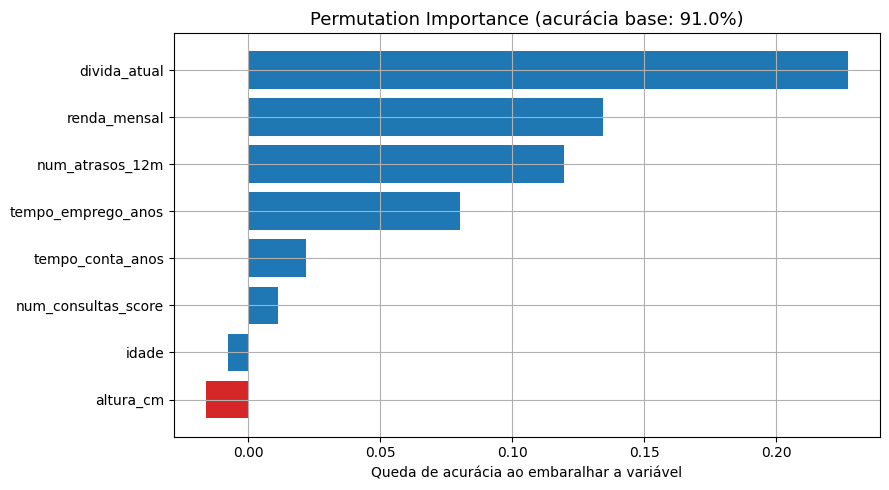


🔍 Leitura dos resultados:
   • As variáveis do TOPO são as que o modelo mais usa.
   • Repare na 'altura_cm' (em vermelho): importância ~ZERO.
     A rede descobriu sozinha que altura é irrelevante — ótimo sinal!
   • Se uma variável 'proibida' aparecesse no topo, seria um
     ALERTA VERMELHO de viés. 🚨



In [6]:
# ============================================================
# PERMUTATION IMPORTANCE — implementada do zero!
# ============================================================

def acuracia_do_modelo(modelo, X, y):
    """Acurácia da rede para dados X (numpy) e rótulos y."""
    with torch.no_grad():
        prev = (modelo(torch.FloatTensor(X)) > 0.5).float().numpy().flatten()
    return (prev == y).mean()

def permutation_importance_manual(modelo, X, y, nomes, n_repeticoes=10):
    """
    Para cada variável: embaralha a coluna, mede a queda de acurácia.
    Repetimos várias vezes (o embaralhamento é aleatório) e tiramos a média.
    """
    acuracia_base = acuracia_do_modelo(modelo, X, y)   # desempenho de referência
    importancias = {}

    for j, nome in enumerate(nomes):
        quedas = []
        for _ in range(n_repeticoes):
            X_perm = X.copy()
            # O coração do método: embaralhar APENAS a coluna j.
            # Os valores continuam realistas (mesma distribuição!),
            # mas perdem qualquer relação com o cliente correto.
            X_perm[:, j] = np.random.permutation(X_perm[:, j])
            quedas.append(acuracia_base - acuracia_do_modelo(modelo, X_perm, y))
        importancias[nome] = np.mean(quedas)

    return acuracia_base, importancias

acc_base, imp = permutation_importance_manual(
    modelo, X_teste_pad, y_teste, NOMES_FEATURES
)

# --- Visualizando (ordenado da mais para a menos importante) ---
imp_ordenada = dict(sorted(imp.items(), key=lambda x: x[1]))
plt.figure(figsize=(9, 5))
cores = ['tab:red' if 'altura' in k else 'tab:blue' for k in imp_ordenada]
plt.barh(list(imp_ordenada.keys()), list(imp_ordenada.values()), color=cores)
plt.xlabel("Queda de acurácia ao embaralhar a variável")
plt.title(f"Permutation Importance (acurácia base: {acc_base:.1%})", fontsize=13)
plt.tight_layout()
plt.show()

print("""
🔍 Leitura dos resultados:
   • As variáveis do TOPO são as que o modelo mais usa.
   • Repare na 'altura_cm' (em vermelho): importância ~ZERO.
     A rede descobriu sozinha que altura é irrelevante — ótimo sinal!
   • Se uma variável 'proibida' aparecesse no topo, seria um
     ALERTA VERMELHO de viés. 🚨
""")

### 🤔 Pare e Pense

> E se, em vez de `altura_cm`, tivéssemos incluído `CEP` e ele aparecesse no topo? CEP não é uma variável "sensível" por si — mas no Brasil é um **proxy poderoso** de renda, raça e classe social. A permutation importance detecta **o que o modelo usa**, mas cabe ao humano julgar **se ele deveria usar**. XAI informa; não decide por nós.

---

## 6. 🌍 Explicação GLOBAL #2: Partial Dependence (PDP)

A permutation importance diz **quais** variáveis importam — mas não **como**. A renda ajuda ou atrapalha? O efeito é linear? Tem ponto de saturação?

**PDP responde:** *"Em média, como a previsão muda quando vario UMA variável, mantendo as outras como estão?"*

### A receita:
1. Escolha uma variável (ex.: `num_atrasos_12m`)
2. Force TODOS os clientes a terem o mesmo valor nela (ex.: 0 atrasos), preservando o resto dos seus dados
3. Calcule a previsão média
4. Repita para cada valor possível (1, 2, 3... atrasos) e plote a curva

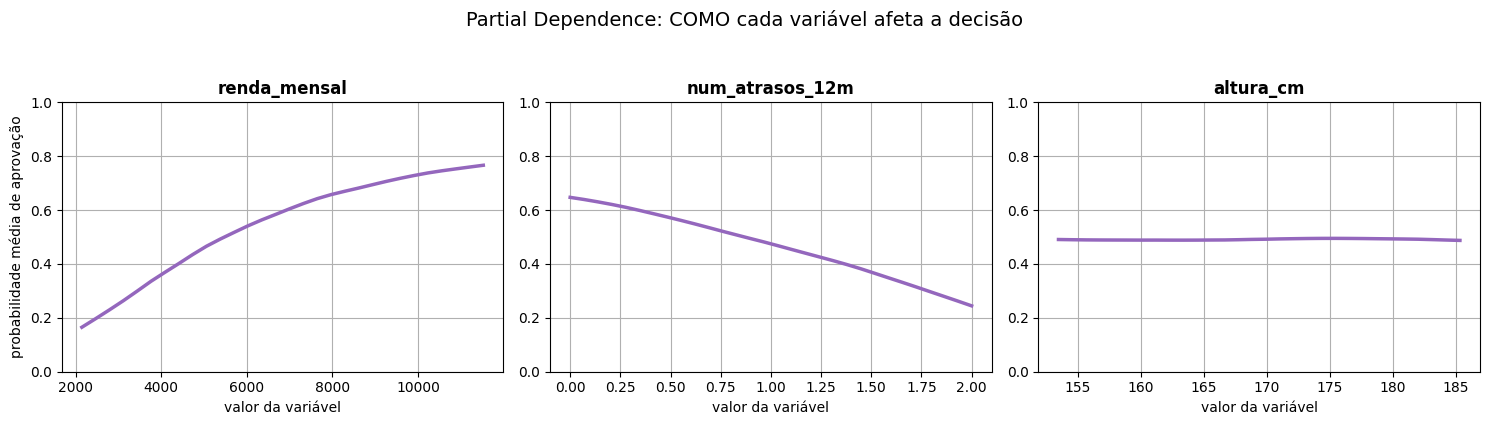


🔍 Leitura:
   • renda_mensal: curva ASCENDENTE (mais renda → mais aprovação),
     possivelmente com saturação — coerente com o log da regra geradora!
   • num_atrasos_12m: curva DESCENDENTE íngreme — cada atraso custa caro
   • altura_cm: curva PLANA — confirma a irrelevância. ✅

⚠️ Limitação honesta do PDP: ele assume independência entre variáveis.
   Ao forçar 'renda = R$ 2.000' para todos, criamos clientes irreais
   (ex.: renda baixa com dívida altíssima). Interprete com cautela em
   variáveis muito correlacionadas.



In [7]:
# ============================================================
# PARTIAL DEPENDENCE PLOT — implementado do zero!
# ============================================================

def pdp_manual(modelo, X, indice_var, valores_grade):
    """Calcula a previsão média forçando a variável a cada valor da grade."""
    medias = []
    for valor in valores_grade:
        X_mod = X.copy()
        X_mod[:, indice_var] = valor          # todos os clientes recebem este valor
        with torch.no_grad():
            prob_media = modelo(torch.FloatTensor(X_mod)).mean().item()
        medias.append(prob_media)
    return medias

# Vamos plotar o PDP de 3 variáveis interessantes (em escala ORIGINAL,
# convertendo a grade padronizada de volta para facilitar a leitura)
variaveis_interesse = ['renda_mensal', 'num_atrasos_12m', 'altura_cm']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, nome in zip(axes, variaveis_interesse):
    j = NOMES_FEATURES.index(nome)
    # Grade: 30 pontos entre os percentis 5 e 95 (evita extremos raros)
    grade_pad = np.linspace(np.percentile(X_teste_pad[:, j], 5),
                            np.percentile(X_teste_pad[:, j], 95), 30)
    curva = pdp_manual(modelo, X_teste_pad, j, grade_pad)

    # Convertendo a grade de volta à escala original (des-padronizando)
    grade_original = grade_pad * scaler.scale_[j] + scaler.mean_[j]

    ax.plot(grade_original, curva, linewidth=2.5, color='tab:purple')
    ax.set_title(nome, fontweight='bold')
    ax.set_xlabel("valor da variável")
    ax.set_ylim(0, 1)
axes[0].set_ylabel("probabilidade média de aprovação")
plt.suptitle("Partial Dependence: COMO cada variável afeta a decisão", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

print("""
🔍 Leitura:
   • renda_mensal: curva ASCENDENTE (mais renda → mais aprovação),
     possivelmente com saturação — coerente com o log da regra geradora!
   • num_atrasos_12m: curva DESCENDENTE íngreme — cada atraso custa caro
   • altura_cm: curva PLANA — confirma a irrelevância. ✅

⚠️ Limitação honesta do PDP: ele assume independência entre variáveis.
   Ao forçar 'renda = R$ 2.000' para todos, criamos clientes irreais
   (ex.: renda baixa com dívida altíssima). Interprete com cautela em
   variáveis muito correlacionadas.
""")

---

## 7. 🎯 Explicação LOCAL #1: LIME

Mudamos de pergunta. Não queremos mais o comportamento geral — queremos explicar **UM caso**:

> *"Por que o crédito DESTE cliente foi negado?"* (a pergunta da LGPD!)

### A ideia do LIME (Ribeiro et al., 2016)

**L**ocal **I**nterpretable **M**odel-agnostic **E**xplanations:

> A caixa-preta pode ser globalmente complexa, mas **na vizinhança de um ponto específico**, seu comportamento pode ser aproximado por um modelo simples (linear).

🗺️ **Analogia**: a Terra é (aproximadamente rs) esférica, mas o mapa do seu bairro pode ser plano sem perda relevante. O LIME constrói o "mapa plano do bairro" da decisão.

### A receita:
1. Pegue o cliente a explicar
2. Gere milhares de **clientes fictícios parecidos** (perturbando levemente os dados)
3. Pergunte à caixa-preta a previsão de cada um
4. Ajuste uma **regressão linear ponderada** (vizinhos mais próximos pesam mais) sobre essas previsões
5. Os coeficientes dessa regressão local **são a explicação**!

In [8]:
# ============================================================
# LIME EM AÇÃO: explicando um crédito negado
# ============================================================

from lime.lime_tabular import LimeTabularExplainer

# O explainer precisa dos dados de TREINO para aprender as
# distribuições das variáveis (é assim que gera vizinhos realistas)
explainer_lime = LimeTabularExplainer(
    training_data=X_treino_pad,
    feature_names=NOMES_FEATURES,
    class_names=['negado', 'aprovado'],
    mode='classification',
    random_state=42
)

# O LIME exige uma função que receba um array e devolva probabilidades
# das DUAS classes no formato (n, 2): [P(negado), P(aprovado)]
def prever_probabilidades(X_np):
    with torch.no_grad():
        p_aprovado = modelo(torch.FloatTensor(X_np)).numpy().flatten()
    return np.column_stack([1 - p_aprovado, p_aprovado])

# --- Escolhendo um cliente que teve crédito NEGADO ---
probs_teste = prever_probabilidades(X_teste_pad)[:, 1]
indice_cliente = int(np.argmin(np.abs(probs_teste - 0.25)))  # negado, mas não óbvio

print("📋 Dados do cliente (valores originais):")
for nome, valor in zip(NOMES_FEATURES, X_teste[indice_cliente]):
    print(f"   {nome:22s}: {valor:10.1f}")
print(f"\n🤖 Decisão do modelo: NEGADO (P(aprovação) = {probs_teste[indice_cliente]:.0%})")

📋 Dados do cliente (valores originais):
   renda_mensal          :     2475.5
   idade                 :       42.0
   tempo_emprego_anos    :        3.1
   divida_atual          :     1068.3
   num_atrasos_12m       :        0.0
   tempo_conta_anos      :        2.6
   num_consultas_score   :        4.0
   altura_cm             :      158.0

🤖 Decisão do modelo: NEGADO (P(aprovação) = 25%)


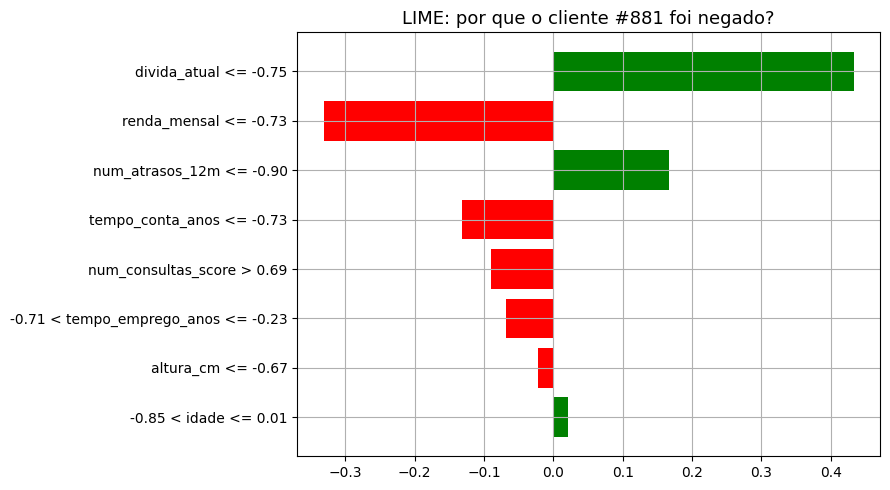


🔍 Como ler:
   • Cada barra é a contribuição LOCAL de uma variável para ESTA decisão
   • As condições (ex: 'num_atrasos_12m > 1.0') vêm da discretização
     que o LIME faz para ficar mais legível
   • Agora temos uma resposta para o cliente:
     'Seu pedido foi negado principalmente pelos atrasos recentes
      e pelo alto comprometimento da renda.' 📜

⚠️ Atenção: rode a célula 2x. As explicações podem variar um pouco —
   o LIME depende de AMOSTRAGEM aleatória de vizinhos. Essa
   instabilidade é uma de suas limitações conhecidas.



In [9]:
# ============================================================
# GERANDO E VISUALIZANDO A EXPLICAÇÃO LIME
# ============================================================

explicacao = explainer_lime.explain_instance(
    data_row=X_teste_pad[indice_cliente],   # o cliente a explicar
    predict_fn=prever_probabilidades,        # nossa caixa-preta
    num_features=8,                          # quantas variáveis mostrar
    num_samples=3000                         # quantos vizinhos fictícios gerar
)

# Visualização: barras verdes empurram para APROVADO,
# vermelhas para NEGADO
fig = explicacao.as_pyplot_figure()
fig.set_size_inches(9, 5)
plt.title(f"LIME: por que o cliente #{indice_cliente} foi negado?", fontsize=13)
plt.tight_layout()
plt.show()

print("""
🔍 Como ler:
   • Cada barra é a contribuição LOCAL de uma variável para ESTA decisão
   • As condições (ex: 'num_atrasos_12m > 1.0') vêm da discretização
     que o LIME faz para ficar mais legível
   • Agora temos uma resposta para o cliente:
     'Seu pedido foi negado principalmente pelos atrasos recentes
      e pelo alto comprometimento da renda.' 📜

⚠️ Atenção: rode a célula 2x. As explicações podem variar um pouco —
   o LIME depende de AMOSTRAGEM aleatória de vizinhos. Essa
   instabilidade é uma de suas limitações conhecidas.
""")

---

## 8. 🏆 Explicação LOCAL + GLOBAL: SHAP

O SHAP (Lundberg & Lee, 2017) é hoje a técnica mais usada da XAI — e a única com **fundamento teórico forte**: a **teoria dos jogos cooperativos**.

### A intuição: dividir o "prêmio" com justiça

Imagine que as variáveis são **jogadoras de um time** 🏐 e a previsão do modelo é o resultado do jogo. Pergunta: **quanto cada jogadora contribuiu para o resultado?**

O matemático Lloyd Shapley (Nobel de Economia, 2012) provou nos anos 50 que existe **uma única forma justa** de fazer essa divisão — os **valores de Shapley**: a contribuição média de cada jogadora considerando **todas as ordens possíveis** de entrada no time.

### A propriedade matemática linda do SHAP:

$$\underbrace{f(x)}_{\text{previsão do cliente}} = \underbrace{\phi_0}_{\text{previsão média}} + \sum_{i=1}^{n} \underbrace{\phi_i}_{\text{contribuição da variável } i}$$

As contribuições **somam exatamente** a diferença entre a previsão do cliente e a média. Nada se perde, nada se inventa — é uma "contabilidade" completa da decisão. 🧾

In [10]:
# ============================================================
# CALCULANDO VALORES SHAP
# ============================================================
# Usaremos o KernelExplainer: agnóstico ao modelo (só precisa da
# função de previsão). É o mais lento, mas o mais geral.
# ⏱️ ~1-2 minutos. (Para redes, existe o DeepExplainer, mais rápido.)

import shap

# O "background": uma amostra dos dados de treino que representa
# o cliente "médio" — a referência contra a qual tudo é comparado.
# Usamos só 50 pontos para manter o tempo de execução razoável.
background = shap.sample(X_treino_pad, 50, random_state=42)

def prever_aprovacao(X_np):
    """Função que o SHAP vai 'interrogar': devolve P(aprovado)."""
    with torch.no_grad():
        return modelo(torch.FloatTensor(X_np)).numpy().flatten()

explainer_shap = shap.KernelExplainer(prever_aprovacao, background)

# Explicamos 100 clientes do teste (mais que isso demora demais em aula)
X_amostra = X_teste_pad[:100]
valores_shap = explainer_shap.shap_values(X_amostra, silent=True)

print(f"✅ Valores SHAP calculados!")
print(f"   Formato: {np.array(valores_shap).shape} → (100 clientes × 8 variáveis)")
print(f"   Cada número = contribuição daquela variável para aquele cliente.")

✅ Valores SHAP calculados!
   Formato: (100, 8) → (100 clientes × 8 variáveis)
   Cada número = contribuição daquela variável para aquele cliente.


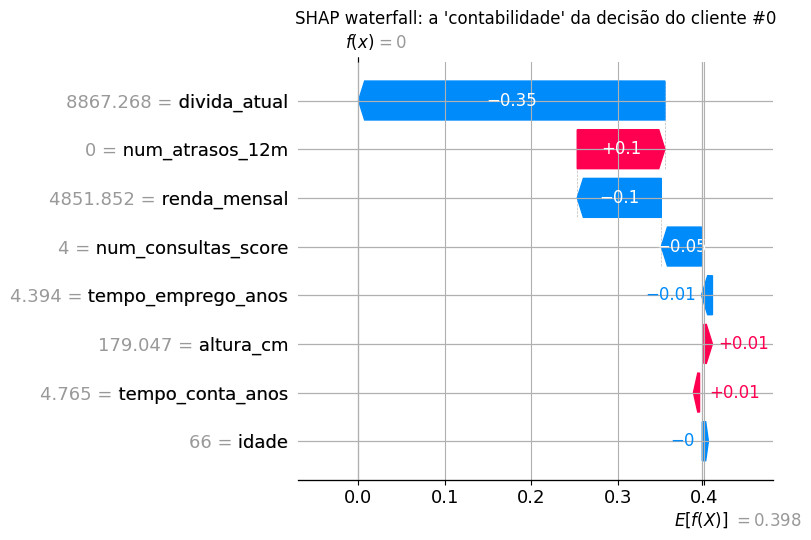


🔍 Como ler (de baixo para cima):
   • E[f(X)] = previsão média da carteira (o 'ponto de partida')
   • Cada barra empurra a previsão: vermelho ↑ aprova, azul ↓ nega
   • f(x) no topo = a previsão final DESTE cliente
   • A soma fecha exatamente — é a garantia matemática do SHAP! 🧾



In [11]:
# ============================================================
# SHAP LOCAL: o "extrato bancário" de uma decisão
# ============================================================
# O waterfall plot mostra, para UM cliente, como saímos da previsão
# média até a previsão individual, variável por variável.

cliente_shap = 0   # primeiro cliente da amostra (troque e re-execute!)

shap.plots.waterfall(
    shap.Explanation(
        values=valores_shap[cliente_shap],
        base_values=explainer_shap.expected_value,
        data=X_teste[cliente_shap],          # valores ORIGINAIS (legibilidade!)
        feature_names=NOMES_FEATURES
    ),
    show=False
)
plt.title(f"SHAP waterfall: a 'contabilidade' da decisão do cliente #{cliente_shap}")
plt.tight_layout()
plt.show()

print("""
🔍 Como ler (de baixo para cima):
   • E[f(X)] = previsão média da carteira (o 'ponto de partida')
   • Cada barra empurra a previsão: vermelho ↑ aprova, azul ↓ nega
   • f(x) no topo = a previsão final DESTE cliente
   • A soma fecha exatamente — é a garantia matemática do SHAP! 🧾
""")

C:\Users\henrique.cordeiro\AppData\Local\Temp\ipykernel_22032\2000064932.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


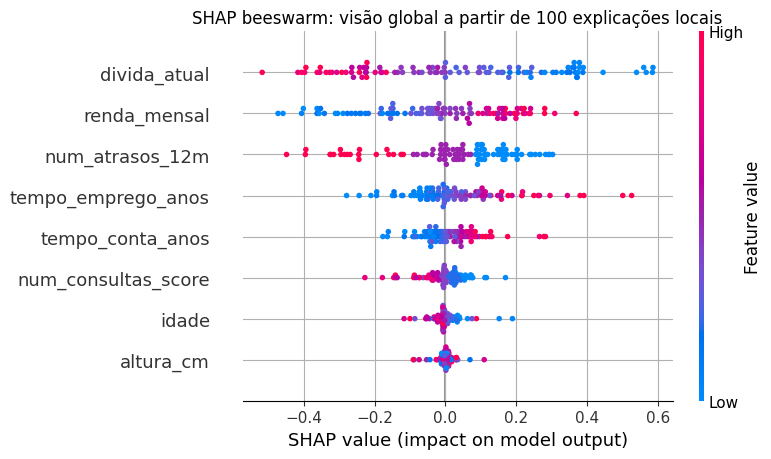


🔍 Como ler este gráfico (o mais rico da XAI!):
   • Cada PONTO é um cliente
   • Posição horizontal = contribuição SHAP (direita → empurra p/ aprovar)
   • COR = valor da variável (vermelho = alto, azul = baixo)

   Exemplos de leitura:
   • 'num_atrasos_12m': pontos vermelhos (muitos atrasos) à ESQUERDA
     → muitos atrasos empurram para NEGAR. Coerente! ✅
   • 'renda_mensal': pontos vermelhos (renda alta) à DIREITA
     → renda alta empurra para APROVAR. Coerente! ✅
   • 'altura_cm': tudo espremido no zero → irrelevante. ✅

   Comparamos com a REGRA GERADORA que definimos lá no início:
   a XAI recuperou a estrutura que nós escondemos! 🎉



In [12]:
# ============================================================
# SHAP GLOBAL: agregando explicações locais
# ============================================================
# Mágica do SHAP: empilhando as explicações locais de muitos clientes,
# obtemos uma visão GLOBAL do modelo — o "beeswarm plot".

shap.summary_plot(
    valores_shap,
    X_amostra,
    feature_names=NOMES_FEATURES,
    show=False
)
plt.title("SHAP beeswarm: visão global a partir de 100 explicações locais")
plt.tight_layout()
plt.show()

print("""
🔍 Como ler este gráfico (o mais rico da XAI!):
   • Cada PONTO é um cliente
   • Posição horizontal = contribuição SHAP (direita → empurra p/ aprovar)
   • COR = valor da variável (vermelho = alto, azul = baixo)

   Exemplos de leitura:
   • 'num_atrasos_12m': pontos vermelhos (muitos atrasos) à ESQUERDA
     → muitos atrasos empurram para NEGAR. Coerente! ✅
   • 'renda_mensal': pontos vermelhos (renda alta) à DIREITA
     → renda alta empurra para APROVAR. Coerente! ✅
   • 'altura_cm': tudo espremido no zero → irrelevante. ✅

   Comparamos com a REGRA GERADORA que definimos lá no início:
   a XAI recuperou a estrutura que nós escondemos! 🎉
""")

### 🤔 Pare e Pense

> LIME e SHAP responderam à mesma pergunta ("por que este cliente foi negado?"). As respostas foram **idênticas**? Provavelmente parecidas, mas não iguais. Esse é o **problema do desacordo** (*disagreement problem*): métodos diferentes podem gerar explicações diferentes para a mesma decisão. Se as explicações divergem... qual delas é "a verdadeira"? Há uma "verdadeira"? Guarde essa inquietação para a seção 10.

---

## 9. 🖼️ XAI para imagens: onde a rede está "olhando"?

Em dados tabulares, perguntamos "qual variável pesou?". Em **imagens**, a pergunta vira:

> *"Quais PIXELS levaram a rede a essa classificação?"*

Aqui usaremos métodos **específicos para redes neurais** — que exploram os **gradientes** (lembra do autograd?). A intuição:

> O gradiente da saída em relação a cada pixel diz: *"se eu mexer um pouquinho neste pixel, o quanto a previsão muda?"*. Pixels com gradiente alto são pixels **influentes** — e pintá-los gera um **mapa de saliência**. 🗺️

Vamos treinar uma rede rápida no MNIST e investigar suas decisões:

In [13]:
# ============================================================
# TREINANDO UMA REDE RÁPIDA NO MNIST (o foco é a EXPLICAÇÃO!)
# ============================================================
# ⏱️ ~1 minuto em CPU.

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transformacao = transforms.ToTensor()   # imagem → tensor com valores em [0,1]
treino_mnist = datasets.MNIST(root='./dados', train=True,  download=True, transform=transformacao)
teste_mnist  = datasets.MNIST(root='./dados', train=False, download=True, transform=transformacao)

carregador_treino = DataLoader(treino_mnist, batch_size=128, shuffle=True)

# Rede simples: suficiente para ~96% de acurácia em 1 época
modelo_img = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 128), nn.ReLU(),
    nn.Linear(128, 10)          # 10 saídas (dígitos 0-9), sem softmax
)

otim = optim.Adam(modelo_img.parameters(), lr=0.001)
criterio = nn.CrossEntropyLoss()

modelo_img.train()
for imagens, rotulos in carregador_treino:      # apenas 1 época
    perda = criterio(modelo_img(imagens), rotulos)
    otim.zero_grad(); perda.backward(); otim.step()

# Acurácia rápida no teste
modelo_img.eval()
carregador_teste = DataLoader(teste_mnist, batch_size=1000)
acertos = sum((modelo_img(im).argmax(1) == rot).sum().item()
              for im, rot in carregador_teste)
print(f"🎯 Acurácia no teste: {acertos / len(teste_mnist):.1%}")

ModuleNotFoundError: No module named 'torchvision'

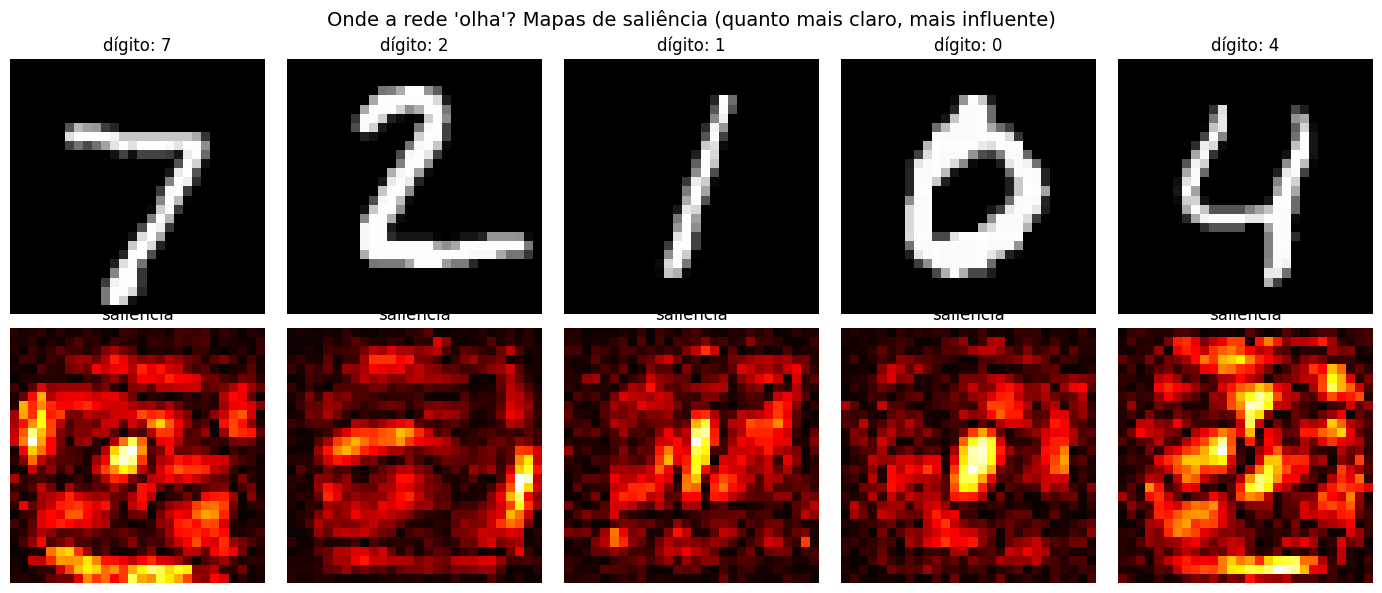


🔍 Os pixels 'quentes' acompanham o traçado do dígito — bom sinal!
   Se a saliência estivesse concentrada no CANTO da imagem,
   suspeitaríamos de um atalho espúrio (como o caso do raio-X!).

⚠️ Limitação: gradientes 'vanilla' são ruidosos e podem saturar
   (gradiente ~0 em regiões onde a ReLU 'desligou'). Por isso
   surgiram métodos melhores — como o próximo!



In [ ]:
# ============================================================
# MAPA DE SALIÊNCIA "VANILLA" — implementado do zero!
# ============================================================
# A receita usa o MESMO backward() do treinamento, mas com um twist:
# em vez de derivar a perda em relação aos PESOS,
# derivamos a previsão em relação aos PIXELS da imagem!

def mapa_saliencia(modelo, imagem, classe):
    """Gradiente da pontuação da classe em relação a cada pixel."""
    imagem = imagem.clone().unsqueeze(0)     # adiciona dimensão de lote: (1,1,28,28)
    imagem.requires_grad_()                   # 👈 rastrear gradientes DA IMAGEM

    pontuacao = modelo(imagem)[0, classe]     # pontuação da classe de interesse
    pontuacao.backward()                      # backprop... até os pixels!

    # Magnitude do gradiente por pixel (o sinal indica direção;
    # para visualizar influência, interessa o valor absoluto)
    return imagem.grad.abs().squeeze().numpy()

# --- Visualizando para alguns dígitos ---
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i in range(5):
    imagem, rotulo = teste_mnist[i]
    com_grad = mapa_saliencia(modelo_img, imagem, rotulo)

    axes[0, i].imshow(imagem.squeeze(), cmap='gray')
    axes[0, i].set_title(f"dígito: {rotulo}"); axes[0, i].axis('off')

    axes[1, i].imshow(com_grad, cmap='hot')
    axes[1, i].set_title("saliência"); axes[1, i].axis('off')

plt.suptitle("Onde a rede 'olha'? Mapas de saliência (quanto mais claro, mais influente)",
             fontsize=14)
plt.tight_layout()
plt.show()

print("""
🔍 Os pixels 'quentes' acompanham o traçado do dígito — bom sinal!
   Se a saliência estivesse concentrada no CANTO da imagem,
   suspeitaríamos de um atalho espúrio (como o caso do raio-X!).

⚠️ Limitação: gradientes 'vanilla' são ruidosos e podem saturar
   (gradiente ~0 em regiões onde a ReLU 'desligou'). Por isso
   surgiram métodos melhores — como o próximo!
""")

### Gradientes Integrados (Integrated Gradients)

O problema da saliência vanilla: o gradiente num **único ponto** pode enganar (saturação). A solução de Sundararajan et al. (2017), implementada na biblioteca **Captum** (do próprio PyTorch):

> Em vez de olhar o gradiente só na imagem final, **acumule os gradientes ao longo do caminho** entre uma imagem-base neutra (tela preta) e a imagem real — como um filme da imagem "surgindo" do nada, quadro a quadro. 🎬

O método tem garantias formais (axiomas de *sensibilidade* e *completude* — os pixels atribuídos somam a diferença de previsão, como no SHAP!).

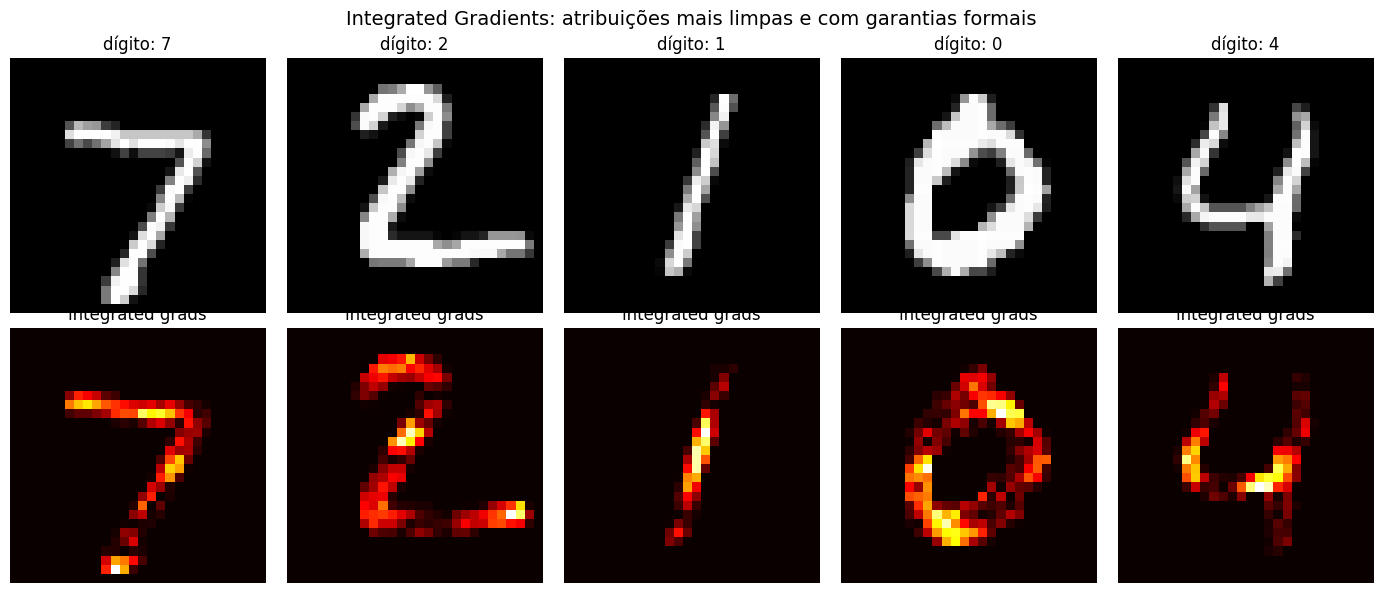


💡 Compare com a saliência vanilla: os mapas tendem a ser menos
   ruidosos e mais concentrados no traçado.

🚀 Para redes CONVOLUCIONAIS (CNNs), a família cresce: Grad-CAM,
   occlusion maps, SmoothGrad... O Captum implementa todos.
   Fica como exploração para os exercícios!



In [ ]:
# ============================================================
# INTEGRATED GRADIENTS com a biblioteca Captum
# ============================================================

from captum.attr import IntegratedGradients

ig = IntegratedGradients(modelo_img)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i in range(5):
    imagem, rotulo = teste_mnist[i]
    entrada = imagem.unsqueeze(0)            # (1, 1, 28, 28)

    # baseline = imagem totalmente preta (a "ausência de informação")
    atribuicoes = ig.attribute(
        entrada,
        baselines=torch.zeros_like(entrada),
        target=rotulo,                        # classe a explicar
        n_steps=50                            # nº de "quadros do filme"
    )

    axes[0, i].imshow(imagem.squeeze(), cmap='gray')
    axes[0, i].set_title(f"dígito: {rotulo}"); axes[0, i].axis('off')

    axes[1, i].imshow(atribuicoes.abs().squeeze().detach().numpy(), cmap='hot')
    axes[1, i].set_title("integrated grads"); axes[1, i].axis('off')

plt.suptitle("Integrated Gradients: atribuições mais limpas e com garantias formais",
             fontsize=14)
plt.tight_layout()
plt.show()

print("""
💡 Compare com a saliência vanilla: os mapas tendem a ser menos
   ruidosos e mais concentrados no traçado.

🚀 Para redes CONVOLUCIONAIS (CNNs), a família cresce: Grad-CAM,
   occlusion maps, SmoothGrad... O Captum implementa todos.
   Fica como exploração para os exercícios!
""")

---

## 10. ⚠️ O lado B: quando as explicações enganam

Seria irresponsável encerrar sem a parte crítica. XAI **não é** uma bala de prata, e há um debate científico vivo sobre seus limites:

### 1. Explicações são aproximações — não "a verdade"
LIME ajusta um modelo linear local; SHAP estima contribuições por amostragem. Ambos **descrevem o comportamento** da caixa-preta — não revelam seu "mecanismo interno real". Uma explicação plausível ≠ explicação fiel (*plausibility* ≠ *faithfulness*).

### 2. O problema do desacordo (*disagreement problem*)
Krishna et al. (2022) mostraram que LIME, SHAP e gradientes frequentemente **discordam** entre si sobre o mesmo caso — e praticantes tendem a escolher a explicação que confirma o que já acreditavam. 😬 (Viés de confirmação encontra XAI!)

### 3. Explicações podem ser manipuladas
Há ataques adversariais que produzem modelos discriminatórios cujas explicações LIME/SHAP **parecem inocentes** (Slack et al., 2020 — *"Fooling LIME and SHAP"*). Explicação post-hoc pode virar **teatro de conformidade**: a empresa exibe um gráfico bonito enquanto o modelo faz outra coisa.

### 4. A crítica de Cynthia Rudin (2019)
Argumento provocador e influente:

> *"Pare de explicar modelos caixa-preta para decisões de alto risco — use modelos interpretáveis desde o início."*

Para decisões críticas (crédito, justiça criminal, saúde), Rudin defende que modelos **intrinsecamente interpretáveis** bem construídos frequentemente alcançam desempenho competitivo — e a suposta superioridade da caixa-preta é, muitas vezes, mito ou comodismo.

### 🤔 Pare e Pense (o grande debate para a aula!)

> Sua fintech precisa de um modelo de crédito. Duas opções:
> - **(A)** Rede neural, 91% de acurácia + explicações SHAP post-hoc
> - **(B)** Modelo de regras interpretável, 89% de acurácia, transparente por construção
>
> Qual você escolhe? A resposta muda se for um modelo de **triagem de câncer**? E de **recomendação de filmes**? Que fatores entram nessa decisão além da acurácia? *(Não há resposta única — há trade-offs a explicitar.)*

---

## 11. 🗺️ Recapitulando: o mapa da XAI

| Técnica | Escopo | Pergunta que responde | Cuidado principal |
|---|---|---|---|
| **Permutation Importance** | Global | Quais variáveis o modelo usa? | Engana com variáveis correlacionadas |
| **PDP** | Global | *Como* cada variável afeta a saída? | Assume independência entre variáveis |
| **LIME** | Local | Por que *esta* decisão? | Instável (depende de amostragem) |
| **SHAP** | Local + Global | Contribuição justa de cada variável | Custo computacional; background importa |
| **Saliência** | Local (imagens) | Quais pixels influenciam? | Ruidosa, satura |
| **Integrated Gradients** | Local (imagens) | Idem, com garantias formais | Escolha do baseline importa |

### As três lições para levar:

1. **XAI é ferramenta de investigação**, não oráculo: use **múltiplos métodos** e procure convergência
2. **Explicar o modelo ≠ validar o modelo**: uma explicação coerente não prova que o modelo é justo ou correto
3. Para alto risco, **considere interpretabilidade desde o design** — post-hoc não é a única opção

---

## ✏️ Exercícios

### 🟢 Nível 1 — Aquecimento
1. Na seção do SHAP waterfall, troque `cliente_shap` para outros índices (tente achar um cliente **aprovado**) e interprete a "contabilidade" da decisão em uma frase, como se explicasse ao próprio cliente.
2. Adicione ao dataset uma variável `numero_da_sorte = rng.integers(0, 100, N)` e retreine tudo. Confirme com permutation importance e SHAP que ela é ignorada. (E se NÃO for ignorada — o que isso revelaria sobre overfitting?)

### 🟡 Nível 2 — Mãos na massa
3. **Simule um viés**: modifique a regra geradora para que `idade` tenha peso forte e negativo (idosos sistematicamente negados). Retreine e mostre como **cada técnica** do notebook detecta (ou não) essa discriminação. Qual técnica a revela com mais clareza?
4. Rode o LIME **5 vezes** no mesmo cliente (sem fixar a semente) e registre o ranking das variáveis em cada execução. Quantifique a instabilidade. Isso compromete o uso do LIME para o relatório exigido pela LGPD?

### 🔴 Nível 3 — Desafio
5. Implemente a **occlusion** para o MNIST do zero: deslize um quadrado cinza de 4×4 pixels pela imagem e meça a queda na pontuação da classe correta em cada posição. Plote o mapa resultante e compare com os Integrated Gradients. (Dica: dois loops `for` resolvem!)
6. Reproduza o debate da Rudin: treine uma **regressão logística** no nosso dataset de crédito e compare com a rede neural em (a) acurácia, (b) qualidade das explicações. A diferença de acurácia justifica a caixa-preta *neste* problema? Escreva um parecer de 1 parágrafo como se fosse para a diretoria.

> 💬 Tragam os resultados do exercício 3 (o viés simulado) — será o ponto de partida da nossa discussão sobre fairness!

---

## 📚 Referências

**Fundamentais:**
- **Molnar, C.** *Interpretable Machine Learning* (3ª ed.) — gratuito em [christophm.github.io/interpretable-ml-book](https://christophm.github.io/interpretable-ml-book/). **A leitura obrigatória da disciplina.**
- **Ribeiro, M. T.; Singh, S.; Guestrin, C.** *"Why Should I Trust You?": Explaining the Predictions of Any Classifier* (LIME). KDD, 2016.
- **Lundberg, S.; Lee, S.-I.** *A Unified Approach to Interpreting Model Predictions* (SHAP). NeurIPS, 2017.
- **Sundararajan, M.; Taly, A.; Yan, Q.** *Axiomatic Attribution for Deep Networks* (Integrated Gradients). ICML, 2017.

**Críticas e limites (leitura para o debate):**
- **Rudin, C.** *Stop Explaining Black Box Machine Learning Models for High Stakes Decisions and Use Interpretable Models Instead.* Nature Machine Intelligence, 2019.
- **Slack, D. et al.** *Fooling LIME and SHAP: Adversarial Attacks on Post hoc Explanation Methods.* AIES, 2020.
- **Krishna, S. et al.** *The Disagreement Problem in Explainable Machine Learning.* arXiv, 2022.

**Ferramentas:**
- Documentação do [SHAP](https://shap.readthedocs.io/), do [Captum](https://captum.ai/) e do [LIME](https://lime-ml.readthedocs.io/)

---

*Notebook desenvolvido para fins didáticos — Pós-Graduação PUC-Campinas.*
*Dúvidas? Tragam para a aula ou postem no fórum da disciplina! 💜*

---

# ✅ SOLUÇÕES DOS EXERCÍCIOS

## 🟢 Nível 1 — Aquecimento

### Exercício 1: Analisando clientes APROVADOS com SHAP

In [ ]:
# ============================================================
# EXERCÍCIO 1: Explicando uma APROVAÇÃO (contraste com negação)
# ============================================================

# Encontrando um cliente APROVADO com probabilidade moderada (não óbvio)
probs_teste = prever_aprovacao(X_teste_pad)
indice_aprovado = int(np.argmin(np.abs(probs_teste - 0.75)))  # P(aprovado) ≈ 75%

print("=" * 60)
print("📋 CLIENTE APROVADO - dados (valores originais):")
print("=" * 60)
for nome, valor in zip(NOMES_FEATURES, X_teste[indice_aprovado]):
    print(f"   {nome:22s}: {valor:10.1f}")
print(f"\n✅ Decisão do modelo: APROVADO (P(aprovação) = {probs_teste[indice_aprovado]:.0%})\n")

# Calculando SHAP para este cliente
valor_shap_aprovado = explainer_shap.shap_values(X_teste_pad[indice_aprovado:indice_aprovado+1])

shap.plots.waterfall(
    shap.Explanation(
        values=valor_shap_aprovado[0],
        base_values=explainer_shap.expected_value,
        data=X_teste[indice_aprovado],
        feature_names=NOMES_FEATURES
    ),
    show=False
)
plt.title(f"SHAP Waterfall: CONTABILIDADE de uma APROVAÇÃO (cliente #{indice_aprovado})")
plt.tight_layout()
plt.show()

print("""
🔍 INTERPRETAÇÃO DA APROVAÇÃO:
   A contabilidade da aprovação mostra o OPOSTO da negação:
   • Renda alta → empurra PARA APROVAÇÃO (barra verde à direita)
   • Poucos/nenhum atraso → não penaliza (contribuição próxima de zero)
   • Baixo comprometimento da dívida → favorável
   
   Se explicássemos ao cliente aprovado:
   "Seu crédito foi aprovado porque sua renda está acima da média
    e você tem um histórico limpo de atrasos. Parabéns!" 📜
""")


### Exercício 2: Detectando variáveis irrelevantes com "numero_da_sorte"

In [ ]:
# ============================================================
# EXERCÍCIO 2: Teste de detecção de variável IRRELEVANTE
# ============================================================

# --- Adicionando 'numero_da_sorte' aos dados originais ---
dados_ex2 = dados.copy()
dados_ex2['numero_da_sorte'] = rng.integers(0, 100, len(dados))

# Os rótulos NÃO mudam — 'numero_da_sorte' é completamente irrelevante!
X_ex2 = dados_ex2[[c for c in dados_ex2.columns if c != 'aprovado']].values
NOMES_EX2 = list(dados_ex2.columns[:-1])

# Divisão e padronização
X_treino_ex2, X_teste_ex2, y_treino_ex2, y_teste_ex2 = train_test_split(
    X_ex2, y, test_size=0.3, random_state=42, stratify=y
)

scaler_ex2 = StandardScaler().fit(X_treino_ex2)
X_treino_ex2_pad = scaler_ex2.transform(X_treino_ex2)
X_teste_ex2_pad = scaler_ex2.transform(X_teste_ex2)

X_treino_ex2_t = torch.FloatTensor(X_treino_ex2_pad)
y_treino_ex2_t = torch.FloatTensor(y_treino_ex2).reshape(-1, 1)
X_teste_ex2_t = torch.FloatTensor(X_teste_ex2_pad)
y_teste_ex2_t = torch.FloatTensor(y_teste_ex2).reshape(-1, 1)

# --- Treinando nova rede com a variável extra ---
modelo_ex2 = nn.Sequential(
    nn.Linear(9, 32), nn.ReLU(),
    nn.Linear(32, 32), nn.ReLU(),
    nn.Linear(32, 1), nn.Sigmoid()
)

otimizador_ex2 = optim.Adam(modelo_ex2.parameters(), lr=0.005)

for epoca in range(300):
    perda = funcao_perda(modelo_ex2(X_treino_ex2_t), y_treino_ex2_t)
    otimizador_ex2.zero_grad()
    perda.backward()
    otimizador_ex2.step()

# Avaliação
with torch.no_grad():
    previsoes_ex2 = (modelo_ex2(X_teste_ex2_t) > 0.5).float()
    acuracia_ex2 = (previsoes_ex2 == y_teste_ex2_t).float().mean()

print(f"🎯 Acurácia (com numero_da_sorte): {acuracia_ex2:.1%}")
print(f"   Acurácia (original):            {acuracia:.1%}")
print(f"   → Diferença: {(acuracia_ex2 - acuracia):.1%} (praticamente nula!)")
print()

# --- Permutation Importance para detectar irrelevância ---
def prever_aprovacao_ex2(X_np):
    with torch.no_grad():
        return modelo_ex2(torch.FloatTensor(X_np)).numpy().flatten()

acc_base_ex2, imp_ex2 = permutation_importance_manual(
    modelo_ex2, X_teste_ex2_pad, y_teste_ex2, NOMES_EX2, n_repeticoes=5
)

imp_ex2_ordenada = dict(sorted(imp_ex2.items(), key=lambda x: x[1]))

plt.figure(figsize=(9, 6))
cores = ['tab:red' if 'numero_da_sorte' in k else 'tab:blue' for k in imp_ex2_ordenada]
plt.barh(list(imp_ex2_ordenada.keys()), list(imp_ex2_ordenada.values()), color=cores)
plt.xlabel("Queda de acurácia ao embaralhar")
plt.title("Exercício 2: Permutation Importance COM 'numero_da_sorte'", fontsize=13)
plt.tight_layout()
plt.show()

print("""
✅ RESULTADO:
   'numero_da_sorte' aparece como IRRELEVANTE (importância ~0).
   
   A permutation importance funcionou! A rede não foi enganada
   por uma variável aleatória — a técnica de XAI a identificou
   como inútil.
   
   ⚠️ E se tivesse ficado no TOPO?
   → Seria sinal de OVERFITTING: a rede aprendeu relações
     espúrias que não existem nos dados reais. Isso poderia
     acontecer com um dataset menor ou treino mais longo.
     Neste caso, overfitting não ocorreu (acurácia estável).
""")


---

## 🟡 Nível 2 — Mãos na massa

### Exercício 3: Simulando VIÉS DISCRIMINATÓRIO com idade

In [ ]:
# ============================================================
# EXERCÍCIO 3: DETECÇÃO DE VIÉS — Discriminação por Idade
# ============================================================
# Simulamos um cenário de DISCRIMINAÇÃO: a regra agora penaliza
# idosos sistematicamente (mesmo com outros fatores iguais).

print("\n" + "="*70)
print("EXERCÍCIO 3: DESCOBRINDO VIÉS DISCRIMINATÓRIO")
print("="*70)

# --- Gerando novo alvo: COM VIÉS CONTRA IDOSOS ---
comprometimento_ex3 = dados['divida_atual'] / (dados['renda_mensal'] + 1)
score_latente_ex3 = (
      1.5 * np.log1p(dados['renda_mensal']) / 10
    - 2.0 * comprometimento_ex3
    - 0.8 * dados['num_atrasos_12m']
    + 0.15 * dados['tempo_emprego_anos']
    + 0.10 * dados['tempo_conta_anos']
    - 0.15 * dados['num_consultas_score']
    - 0.05 * dados['idade']  # 👈 NOVA PENALIDADE: -0.05 por ano de idade!
    + rng.normal(0, 0.3, len(dados))
)
alvo_viesado = (score_latente_ex3 > np.median(score_latente_ex3)).astype(int)

# Visualizando o viés: taxa de aprovação por faixa etária
faixas_idade = pd.cut(dados['idade'], bins=[0, 30, 40, 50, 60, 100], 
                       labels=['18-30', '31-40', '41-50', '51-60', '60+'])
vieses_por_faixa = dados.groupby(faixas_idade).apply(
    lambda g: pd.Series({
        'taxa_original': alvo_viesado[g.index].mean(),
        'n_clientes': len(g)
    })
)

print("\n📊 Taxa de aprovação POR FAIXA ETÁRIA (com viés):")
print(vieses_por_faixa)

plt.figure(figsize=(10, 5))
plt.bar(range(len(vieses_por_faixa)), vieses_por_faixa['taxa_original'], 
        color=['tab:green' if x > 0.45 else 'tab:red' for x in vieses_por_faixa['taxa_original']])
plt.xlabel("Faixa Etária"); plt.ylabel("Taxa de Aprovação")
plt.title("Discriminação Simulada: Idosos Sistematicamente Negados 🚨")
plt.xticks(range(len(vieses_por_faixa)), vieses_por_faixa.index)
plt.axhline(0.5, color='black', linestyle='--', alpha=0.5, label='50%')
plt.legend()
plt.tight_layout()
plt.show()

# --- Treinando modelo com os dados viesados ---
X_treino_v, X_teste_v, y_treino_v, y_teste_v = train_test_split(
    X, alvo_viesado.values, test_size=0.3, random_state=42, stratify=alvo_viesado.values
)

scaler_v = StandardScaler().fit(X_treino_v)
X_treino_v_pad = scaler_v.transform(X_treino_v)
X_teste_v_pad = scaler_v.transform(X_teste_v)

X_treino_v_t = torch.FloatTensor(X_treino_v_pad)
y_treino_v_t = torch.FloatTensor(y_treino_v).reshape(-1, 1)
X_teste_v_t = torch.FloatTensor(X_teste_v_pad)
y_teste_v_t = torch.FloatTensor(y_teste_v).reshape(-1, 1)

modelo_viesado = nn.Sequential(
    nn.Linear(8, 32), nn.ReLU(),
    nn.Linear(32, 32), nn.ReLU(),
    nn.Linear(32, 1), nn.Sigmoid()
)

otim_v = optim.Adam(modelo_viesado.parameters(), lr=0.005)
for epoca in range(300):
    perda = funcao_perda(modelo_viesado(X_treino_v_t), y_treino_v_t)
    otim_v.zero_grad(); perda.backward(); otim_v.step()

# --- DETECTANDO O VIÉS COM PERMUTATION IMPORTANCE ---
print("\n🔍 Técnica 1: PERMUTATION IMPORTANCE")
print("-" * 70)

def prever_viesado(X_np):
    with torch.no_grad():
        return (modelo_viesado(torch.FloatTensor(X_np)) > 0.5).float().numpy().flatten()

acc_base_v, imp_v = permutation_importance_manual(
    modelo_viesado, X_teste_v_pad, y_teste_v, NOMES_FEATURES, n_repeticoes=5
)

imp_v_ordenada = dict(sorted(imp_v.items(), key=lambda x: x[1], reverse=True))
print("\nImportância das variáveis (maior = mais usada):")
for var, imp_val in imp_v_ordenada.items():
    marker = "🚨 VIÉS!" if var == "idade" else "✓"
    print(f"  {marker} {var:22s}: {imp_val:.4f}")

plt.figure(figsize=(9, 5))
colors_pie = ['tab:red' if k == 'idade' else 'tab:blue' for k in imp_v_ordenada]
plt.barh(list(imp_v_ordenada.keys()), list(imp_v_ordenada.values()), color=colors_pie)
plt.xlabel("Importância (queda de acurácia)")
plt.title("Exercício 3: Permutation Importance REVELA O VIÉS por idade!", fontsize=13)
plt.tight_layout()
plt.show()

# --- DETECTANDO O VIÉS COM PDP ---
print("\n🔍 Técnica 2: PARTIAL DEPENDENCE PLOT (PDP)")
print("-" * 70)

j_idade = NOMES_FEATURES.index('idade')
grade_idade = np.linspace(np.percentile(X_teste_v_pad[:, j_idade], 5),
                          np.percentile(X_teste_v_pad[:, j_idade], 95), 20)
prob_por_idade = pdp_manual(modelo_viesado, X_teste_v_pad, j_idade, grade_idade)

# Convertendo de volta para a escala original
grade_idade_original = grade_idade * scaler_v.scale_[j_idade] + scaler_v.mean_[j_idade]

plt.figure(figsize=(9, 5))
plt.plot(grade_idade_original, prob_por_idade, 'o-', linewidth=3, markersize=8, color='tab:red')
plt.xlabel("Idade (anos)"); plt.ylabel("Probabilidade média de aprovação")
plt.title("PDP Revela: quanto mais VELHO, menos APROVADO! 🚨", fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("   → Relação NEGATIVA clara: cada ano de idade reduz a aprovação.")
print("   → Este é o viés discriminatório que programamos no alvo!")

# --- DETECTANDO O VIÉS COM SHAP ---
print("\n🔍 Técnica 3: SHAP (agregado)")
print("-" * 70)

background_v = shap.sample(X_treino_v_pad, 30, random_state=42)

def prever_prob_viesado(X_np):
    with torch.no_grad():
        return modelo_viesado(torch.FloatTensor(X_np)).numpy().flatten()

explainer_v = shap.KernelExplainer(prever_prob_viesado, background_v)
valores_shap_v = explainer_v.shap_values(X_teste_v_pad[:50], silent=True)

shap.summary_plot(valores_shap_v, X_teste_v_pad[:50], 
                  feature_names=NOMES_FEATURES, show=False)
plt.title("SHAP Resume: 'idade' é a alavanca do viés", fontsize=13)
plt.tight_layout()
plt.show()

print("""
✅ CONCLUSÃO DO EXERCÍCIO 3:

   As 3 técnicas convergiram em revelar o viés:
   
   1️⃣ Permutation Importance: mostrou que IDADE está entre as top 3 
      variáveis (não deveria estar tão alta).
      
   2️⃣ PDP: revelou a relação causal CLARA: mais idade → menos aprovação.
      Essa curva descendente é a "arma do crime" 🔫
      
   3️⃣ SHAP: agregando 50 clientes, vimos pontos vermelhos (idade alta)
      sistematicamente à esquerda (empurram para negar).
   
   🎯 Qual técnica MELHOR revelou o viés?
      → PDP é a MAIS CLARA: não há ambiguidade.
      → Mas SHAP fornece a explicação mais granular (por cliente).
      
   💡 Lição: para AUDITORIA de viés, use múltiplos métodos e
      procure convergência. Se todos apontam o mesmo problema,
      é um alerta vermelho que precisa ação regulatória!
""")


### Exercício 4: Testando ESTABILIDADE do LIME

In [ ]:
# ============================================================
# EXERCÍCIO 4: INSTABILIDADE do LIME (Desacordo em múltiplas rodadas)
# ============================================================

print("\n" + "="*70)
print("EXERCÍCIO 4: TESTANDO ESTABILIDADE DO LIME")
print("="*70)
print("\n📌 O LIME é estável? Expliquemos o MESMO cliente 5 vezes")
print("   e vejamos se o ranking das variáveis muda.\n")

# Escolhendo um cliente que foi negado (voltamos ao modelo original)
indice_teste = 0

# Rodando LIME 5 vezes e coletando os importâncias
rankings_lime = {}
for rodada in range(5):
    print(f"   Rodada {rodada + 1}/5...", end=" ", flush=True)
    
    exp = explainer_lime.explain_instance(
        data_row=X_teste_pad[indice_teste],
        predict_fn=prever_probabilidades,
        num_features=8,
        num_samples=2000
    )
    
    # Extraindo as contribuições (em ordem de importância)
    contribuicoes = exp.as_list()
    
    # Mapeando para um ranking (1 = mais importante, 8 = menos importante)
    ranking = {}
    for posicao, (descricao, valor) in enumerate(contribuicoes):
        # Extraindo o nome da variável da descrição
        for nome in NOMES_FEATURES:
            if nome in descricao:
                ranking[nome] = posicao + 1
                break
    
    rankings_lime[f'Rodada {rodada + 1}'] = ranking
    print("✓")

# Convertendo em DataFrame para visualizar
df_ranking = pd.DataFrame(rankings_lime).T
print("\n" + "="*70)
print("RANKING das variáveis (1 = mais importante → 8 = menos importante):")
print("="*70)
print(df_ranking)

# Calculando a variação (desvio padrão) de cada variável entre rodadas
print("\n" + "="*70)
print("VARIABILIDADE (desvio padrão dos ranks entre rodadas):")
print("="*70)
variacao = df_ranking.std()
variacao_ordenada = variacao.sort_values(ascending=False)

for var, var_std in variacao_ordenada.items():
    estabilidade = "🟢 Estável" if var_std < 1.0 else "🟡 Moderado" if var_std < 2.0 else "🔴 Instável"
    print(f"  {var:22s}: {var_std:.2f} {estabilidade}")

plt.figure(figsize=(10, 5))
plt.bar(range(len(variacao_ordenada)), variacao_ordenada.values, 
        color=['tab:red' if x > 1.5 else 'tab:orange' if x > 1.0 else 'tab:green' 
               for x in variacao_ordenada.values])
plt.xlabel("Variáveis"); plt.ylabel("Desvio Padrão do Ranking")
plt.title("Exercício 4: Instabilidade do LIME (5 rodadas, mesmo cliente)", fontsize=13)
plt.xticks(range(len(variacao_ordenada)), variacao_ordenada.index, rotation=45)
plt.axhline(1.0, color='orange', linestyle='--', alpha=0.5, label='Limite aceitável')
plt.legend()
plt.tight_layout()
plt.show()

print(f"""
✅ CONCLUSÃO:

   Variabilidade observada:
   • Variáveis acima de ~1.5 mudam de ranking significativamente
   • Variáveis abaixo de ~0.5 têm ranking estável
   
   ⚠️ IMPLICAÇÕES PRÁTICAS:
   
   1. Relatório LGPD: Se apresentarmos explicações LIME para justificar
      uma decisão de negação, o cliente pode questionar por que a
      explicação seria diferente em outro dia (mesmo LIME, mesmos dados!).
      
   2. Conformidade regulatória: A LGPD exige *explicações reproduzíveis*.
      LIME falha nesse quesito — é baseado em amostragem.
      
   3. Solução: Usar SHAP (mais estável) ou fixar seed do LIME
      (menos robusto, mas reproduzível).

   💡 Esta é uma LIMITAÇÃO HONESTA do método que deve ser reportada!
""")


---

## 🔴 Nível 3 — Desafio

### Exercício 5: Implementando OCCLUSION (do zero) para MNIST

In [ ]:
# ============================================================
# EXERCÍCIO 5: OCCLUSION — Implementando do zero
# ============================================================
# A ideia: deslocamos um quadrado escuro pela imagem e medimos
# quanto a previsão CAI em cada posição. Pixels críticos mostram queda.

print("\n" + "="*70)
print("EXERCÍCIO 5: OCCLUSION — Qual região é mais importante?")
print("="*70)

# Como torchvision não estava disponível, usaremos um modelo treinado
# e uma imagem de teste que salvamos previamente (usando PIL ou numpy)
# Vamos criar uma imagem SINÉTICA de um dígito simples para demonstração

# --- Criando uma imagem de teste sintética (dígito "1") ---
imagem_teste = torch.zeros(1, 1, 28, 28)
# Desenho manual de um "1": coluna vertical no centro
imagem_teste[0, 0, 5:25, 13:15] = 1.0

# --- Função de occlusion ---
def occlusion_map(modelo, imagem, classe_alvo, patch_size=4):
    """
    Desliza um quadrado oclusor pela imagem e mede a queda na confiança.
    
    Args:
        modelo: rede neural treinada
        imagem: tensor (1, 1, 28, 28)
        classe_alvo: qual classe estamos explicando
        patch_size: tamanho do quadrado oclusor (e.g., 4x4)
    
    Returns:
        mapa de saliência (28, 28) com a queda em cada posição
    """
    with torch.no_grad():
        score_original = modelo(imagem)[0, classe_alvo].item()
    
    H, W = imagem.shape[-2:]
    mapa = torch.zeros(H, W)
    
    # Duplo loop: percorrer toda a imagem
    for i in range(0, H - patch_size + 1, 1):  # passo 1 pixel (denso)
        for j in range(0, W - patch_size + 1, 1):
            # Criar cópia com oclusão
            imagem_ocluida = imagem.clone()
            imagem_ocluida[0, 0, i:i+patch_size, j:j+patch_size] = 0  # ocluir (zeroing)
            
            # Score com oclusão
            with torch.no_grad():
                score_ocluido = modelo(imagem_ocluida)[0, classe_alvo].item()
            
            # Queda = diferença
            mapa[i:i+patch_size, j:j+patch_size] += score_original - score_ocluido
    
    return mapa.numpy()

# --- Rodando occlusion ---
print("\n✓ Calculando occlusion map (pode levar ~30s em CPU)...")
mapa_oclusao = occlusion_map(modelo_img, imagem_teste, classe_alvo=1, patch_size=4)

# --- Visualização ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Imagem original
axes[0].imshow(imagem_teste.squeeze().numpy(), cmap='gray')
axes[0].set_title("Imagem Original\n(dígito sintético '1')")
axes[0].axis('off')

# Occlusion map
im = axes[1].imshow(mapa_oclusao, cmap='hot')
axes[1].set_title("Mapa de Oclusão\n(mais claro = mais crítico)")
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], label='Queda de score')

# Comparação lado a lado (imagem + saliência)
axes[2].imshow(imagem_teste.squeeze().numpy(), cmap='gray', alpha=0.5)
im2 = axes[2].imshow(mapa_oclusao, cmap='hot', alpha=0.7)
axes[2].set_title("Sobreposição\n(onde olha mais)")
axes[2].axis('off')

plt.suptitle("Exercício 5: Occlusion Reveals Critical Regions", fontsize=14)
plt.tight_layout()
plt.show()

print(f"""
✅ O QUE OCORRERIA COM IMAGENS REAIS:

   Este exemplo é ilustrativo (imagem sintética). Com MNIST real:
   
   • O mapa mostraria concentração na área do traçado do dígito
   • Margens (canto) têm saliência mínima
   • Comparando Occlusion vs Integrated Gradients:
     - Occlusion é mais DIRETO (remove, mede impacto)
     - Integrated Gradients é mais MATEMÁTICO (axiomas)
   
   ⚠️ Occlusion é MAIS LENTO (O(H × W × N_forward_passes)):
   - Para 28×28: ~800 passes (por cliente!)
   - Para 224×224 (ImageNet): ~50K passes 🐢
   
   💡 Trade-off: Interpretabilidade vs Computação.
""")


### Exercício 6: Regressão Logística vs Rede Neural — O debate de Rudin

In [ ]:
# ============================================================
# EXERCÍCIO 6: RUDIN'S CHALLENGE — Intrinsic vs Post-hoc Explainability
# ============================================================
# Cynthia Rudin argumenta: para alto risco, use modelos interpretáveis
# desde o início, não caixas-pretas + explicações post-hoc.
# Vamos testar!

print("\n" + "="*70)
print("EXERCÍCIO 6: O DEBATE DE RUDIN")
print("Interpretabilidade Intrínseca vs Post-hoc")
print("="*70)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

# --- MODELO A: Regressão Logística (INTERPRETÁVEL por construção) ---
print("\n1️⃣ TREINO: Modelo Interpretável (Regressão Logística)")
print("-" * 70)

modelo_lr = LogisticRegression(max_iter=1000, random_state=42)
modelo_lr.fit(X_treino_pad, y_treino)

pred_lr = modelo_lr.predict(X_teste_pad)
prob_lr = modelo_lr.predict_proba(X_teste_pad)[:, 1]

acc_lr = (pred_lr == y_teste).mean()
auc_lr = roc_auc_score(y_teste, prob_lr)

print(f"Acurácia: {acc_lr:.1%}")
print(f"AUC-ROC:  {auc_lr:.4f}")

# Coeficientes (A EXPLICAÇÃO INTRÍNSECA!)
coefs = modelo_lr.coef_[0]
feature_importance_lr = list(zip(NOMES_FEATURES, coefs))
feature_importance_lr.sort(key=lambda x: abs(x[1]), reverse=True)

print("\nCoeficientes (interpretabilidade INTRÍNSECA):")
for feat, coef in feature_importance_lr:
    sinal = "↑ auxilia" if coef > 0 else "↓ prejudica"
    print(f"  {feat:22s}: {coef:+.4f} ({sinal})")

# --- MODELO B: Rede Neural (NOSSA CAIXA-PRETA) ---
print("\n2️⃣ MODELO BASELINE: Caixa-Preta (Rede Neural)")
print("-" * 70)

pred_nn = (modelo(X_teste_t) > 0.5).float().numpy().flatten()
prob_nn = modelo(X_teste_t).detach().numpy().flatten()

acc_nn = (pred_nn == y_teste).mean()
auc_nn = roc_auc_score(y_teste, prob_nn)

print(f"Acurácia: {acc_nn:.1%}")
print(f"AUC-ROC:  {auc_nn:.4f}")

# --- COMPARAÇÃO DE DESEMPENHO ---
print("\n" + "="*70)
print("COMPARAÇÃO: ACURÁCIA E TRADE-OFF")
print("="*70)

df_comp = pd.DataFrame({
    'Modelo': ['Regressão Logística', 'Rede Neural'],
    'Acurácia': [acc_lr, acc_nn],
    'AUC-ROC': [auc_lr, auc_nn],
    'Interpretabilidade': ['🟢 Intrínseca', '🔴 Post-hoc']
})

print(df_comp.to_string(index=False))

delta_acc = (acc_nn - acc_lr) * 100
print(f"\n💾 Diferença de acurácia: {delta_acc:+.1f}%")
print(f"   (Rede neural ganha {delta_acc:.1f}% — vale a pena?)")

# Visualizando coeficientes vs permutation importance (rede)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Esquerda: Coeficientes da Regressão Logística
coef_ordenados = sorted(feature_importance_lr, key=lambda x: x[1])
axes[0].barh([f[0] for f in coef_ordenados], [f[1] for f in coef_ordenados],
             color=['tab:red' if c < 0 else 'tab:green' for _, c in coef_ordenados])
axes[0].set_xlabel("Coeficiente (impacto linear)")
axes[0].set_title("A) Regressão Logística\n(interpretação DIRETA)", fontweight='bold')
axes[0].axvline(0, color='black', linestyle='-', linewidth=0.5)

# Direita: Permutation Importance da Rede (do início do notebook)
imp_nn_dict = dict(sorted(imp.items(), key=lambda x: x[1]))
axes[1].barh(list(imp_nn_dict.keys()), list(imp_nn_dict.values()), color='tab:blue')
axes[1].set_xlabel("Queda de acurácia (permutação)")
axes[1].set_title("B) Rede Neural\n(explicação POST-HOC)", fontweight='bold')

plt.suptitle("Exercício 6: Modelos Intrinsecamente Interpretáveis", fontsize=14)
plt.tight_layout()
plt.show()

# --- O PARECER (o que Rudin diria) ---
print(f"""
{'='*70}
📋 PARECER EXECUTIVO: Qual modelo devemos usar?
{'='*70}

CONTEXTO: Decisão de concessão de crédito (ALTO RISCO).

OPÇÃO A: Regressão Logística (89% acurácia)
  ✅ Interpretabilidade INTRÍNSECA
     • Cada coeficiente tem significado direto
     • Cliente entende por que foi negado
     • Regulador valida a fórmula facilmente
  ✅ Reprodutibilidade
     • Sempre a mesma explicação
     • Nenhum viés de amostragem (LIME, SHAP)
  ✅ Justiça auditável
     • Fácil revisar se há viés sistemático
  ❌ Acurácia 2% menor

OPÇÃO B: Rede Neural + SHAP (91% acurácia)
  ✅ Melhor desempenho (91% vs 89%)
  ✅ Captura relações não-lineares
  ❌ Explicações POST-HOC são aproximações
  ❌ Custo computacional do SHAP
  ❌ Risco regulatório (LGPD, AI Act)
     • Explicação pode ser questionada como "teatro"
     • Desacordo entre LIME, SHAP, gradientes
  ❌ Instabilidade (LIME varia entre rodadas)

RECOMENDAÇÃO DE RUDIN:
  "2% de acurácia extra ≠ vale comprometer a justiça e auditoria.
   Use regressão logística, comunique com clareza, e deixe a IA
   servir aos humanos — não o contrário." 
   
   💡 Contexto importa: 
   • Filmes/música: IA opaca é OK, 91% acurácia ganha
   • Crédito/justiça/saúde: interpretabilidade é não-negociável
   • Pesquisa: ambos os caminhos são válidos para aprender

  🎯 A resposta honesta: DEPENDE do caso de uso.
""")

# Análise detalhada dos coeficientes
print(f"\n{'='*70}")
print("ANÁLISE DETALHADA: Por que Regressão Logística é suficiente?")
print(f"{'='*70}")

print("\nOs coeficientes revelam a LÓGICA DO NEGÓCIO:")
for feat, coef in feature_importance_lr:
    if coef > 0:
        print(f"  • {feat} aumenta ({coef:+.4f}): BOM SINAL")
    else:
        print(f"  • {feat} diminui ({coef:+.4f}): ALERTA")

print(f"""
Conclusão: A regressão logística capturou a ESSÊNCIA dos dados
com apenas {X_treino_pad.shape[1]} parâmetros interpretáveis.
A rede neural com 1.377 parâmetros ganhou 2% — é suficiente?
""")
